### 1 Setup

#### Import Libraries

In [1]:
# Data manipulation libraries.
import numpy as np
import pandas as pd

# Data visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Data modeling libraries.
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree

#### Configure Libraries

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100
pd.options.display.max_columns = None

# Configure Seaborn.
# sns.set_style("whitegrid")
sns.set_palette("deep")

#### Import Dataset

In [3]:
emp_df = pd.read_csv("data/employee_attrition_synthetic_dataset.csv")

display(emp_df.sample(3, random_state=rng))

row_count, col_count = emp_df.shape
print(f"Dataset contains {row_count} rows and {col_count} columns.")

,age,ot_hrs,attrition
45,22.4,1.1,0
6,46.1,1.5,0
53,35.1,3.0,0


Dataset contains 70 rows and 3 columns.


#### Objective

1. Perform EDA
2. Plot Decision Tree
3. Check Feature Importance

### 2 EDA

#### Metadata

In [4]:
emp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        70 non-null     float64
 1   ot_hrs     70 non-null     float64
 2   attrition  70 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.8 KB


#### Target Variable

In [5]:
emp_df["attrition"].value_counts()

attrition
0    42
1    28
Name: count, dtype: int64

#### Features

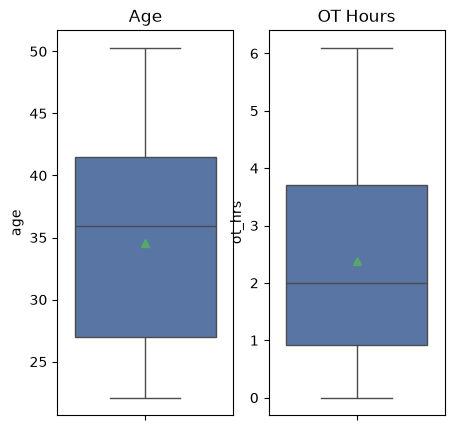

In [6]:
plt.figure(figsize=(5, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=emp_df, y="age", showmeans=True)
plt.title("Age")

plt.subplot(1, 2, 2)
sns.boxplot(data=emp_df, y="ot_hrs", showmeans=True)
plt.title("OT Hours")

plt.show()

#### Feature vs Target

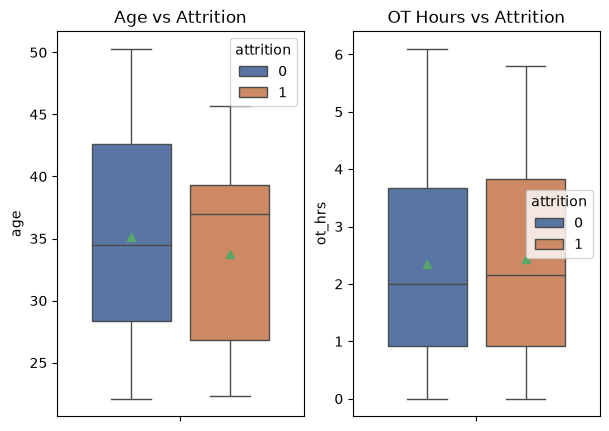

In [7]:
plt.figure(figsize=(7, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=emp_df, y="age", hue="attrition", showmeans=True, gap=0.2)
plt.title("Age vs Attrition")

plt.subplot(1, 2, 2)
sns.boxplot(data=emp_df, y="ot_hrs", hue="attrition", showmeans=True, gap=0.2)
plt.title("OT Hours vs Attrition")

plt.show()

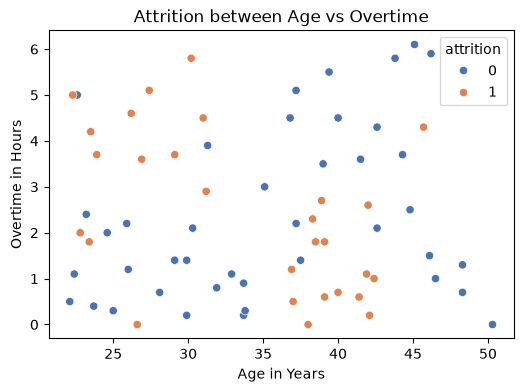

In [8]:
plt.figure(figsize=(6, 4))

sns.scatterplot(data=emp_df, x="age", y="ot_hrs", hue="attrition")
plt.title("Attrition between Age vs Overtime")
plt.xlabel("Age in Years")
plt.ylabel("Overtime in Hours")

plt.show()

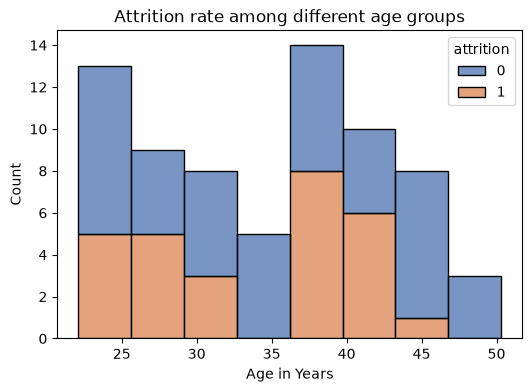

In [9]:
plt.figure(figsize=(6, 4))

sns.histplot(data=emp_df, x="age", hue="attrition", multiple="stack")
plt.title("Attrition rate among different age groups")
plt.xlabel("Age in Years")

plt.show()

In [10]:
def value_count(x):
    """
    Function to return most common class label in
    the input array `x` based on its value count.
    """
    return np.bincount(x).argmax().item()

In [11]:
emp_df2 = emp_df.copy()

oth_bins = [0, 1, 2, 3, 4, 5, 6]
oth_lbls = ["0-1", "1-2", "2-3", "3-4", "4-5", "5-6"]
age_bins = [20, 25, 30, 35, 40, 45, 50]
age_lbls = ["20-25", "25-30", "30-35", "35-40", "40-45", "45-50"]

emp_df2["oth_bins"] = pd.cut(emp_df2["ot_hrs"], bins=oth_bins, labels=oth_lbls)
emp_df2["age_bins"] = pd.cut(emp_df2["age"], bins=age_bins, labels=age_lbls)

camt = emp_df2.pivot_table(
    index="oth_bins",
    columns="age_bins",
    values="attrition",
    aggfunc=lambda x: np.bincount(x).argmax().item(),
)

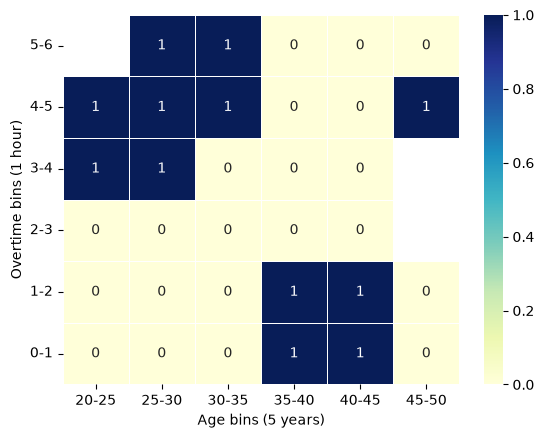

In [12]:
ax = sns.heatmap(camt, cmap="YlGnBu", linecolor="white", linewidth=0.5, annot=True)
plt.xlabel("Age bins (5 years)")
plt.ylabel("Overtime bins (1 hour)")
plt.yticks(rotation=0)
ax.invert_yaxis()

plt.show()

### 3 Entropy

In [13]:
X = emp_df[emp_df.columns.difference(["attrition"])]
y = emp_df["attrition"]

In [14]:
clf1 = DecisionTreeClassifier(criterion="entropy", max_leaf_nodes=5, random_state=42)
clf1.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Plot Decision Tree

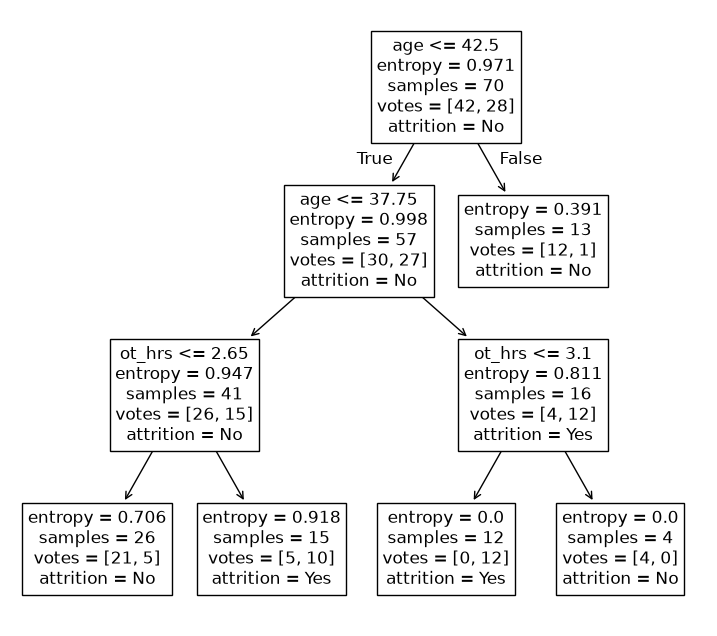

In [15]:
plt.figure(figsize=(9, 8))

plot_tree(clf1, feature_names=X.columns, class_names=["No", "Yes"], fontsize=12)

for annot in plt.gca().texts:
    text = annot.get_text()
    text = text.replace("value =", "votes =")
    text = text.replace("class =", "attrition =")
    annot.set_text(text)

# plt.savefig("images/3_emp_att_dt_entropy.png", bbox_inches="tight")
plt.show()

#### Feature Importance

In [16]:
pd.DataFrame(
    {
        "Feature": clf1.feature_names_in_,
        "Importance": clf1.feature_importances_.round(2),
    }
).sort_values(by="Importance", ascending=False, ignore_index=True)

,Feature,Importance
0,ot_hrs,0.64
1,age,0.36


### 4 Gini Impurity

In [17]:
clf2 = DecisionTreeClassifier(criterion="gini", max_leaf_nodes=5, random_state=42)
clf2.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

#### Plot Decision Tree

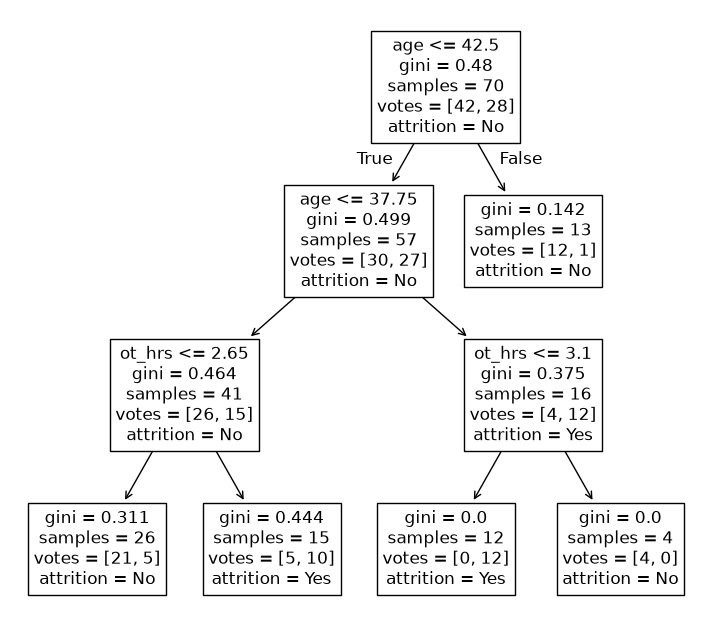

In [18]:
plt.figure(figsize=(9, 8))

plot_tree(clf2, feature_names=X.columns, class_names=["No", "Yes"], fontsize=12)

for annot in plt.gca().texts:
    text = annot.get_text()
    text = text.replace("value =", "votes =")
    text = text.replace("class =", "attrition =")
    annot.set_text(text)

# plt.savefig("images/4_emp_att_dt_gini.png", bbox_inches="tight")
plt.show()

#### Feature Importance

In [19]:
pd.DataFrame(
    {
        "Feature": clf2.feature_names_in_,
        "Importance": clf2.feature_importances_.round(2),
    }
).sort_values(by="Importance", ascending=False, ignore_index=True)

,Feature,Importance
0,ot_hrs,0.6
1,age,0.4


### 5 Training Setup

In [20]:
emp_df.columns

Index(['age', 'ot_hrs', 'attrition'], dtype='str')

In [21]:
X = emp_df[emp_df.columns.difference(["attrition"])]
y = emp_df["attrition"]

#### Train test split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((49, 2), (21, 2), (49,), (21,))

In [23]:
pd.DataFrame(
    {
        "Count": (counts := y_train.value_counts()),
        "Percentage": round(counts / counts.sum() * 100, 2),
    }
)

,Count,Percentage
attrition,,
0,29,59.18
1,20,40.82


In [24]:
pd.DataFrame(
    {
        "Count": (counts := y_test.value_counts()),
        "Percentage": round(counts / counts.sum() * 100, 2),
    }
)

,Count,Percentage
attrition,,
0,13,61.9
1,8,38.1


### 6 Training

#### Base Model

In [25]:
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Training Accuracy

In [26]:
tr_acc = base_model.score(X_train, y_train)
print("Training accuracy:", round(tr_acc * 100, 2))

Training accuracy: 97.96


#### Testing Accuracy

In [27]:
ts_acc = base_model.score(X_test, y_test)
print("Testing accuracy:", round(ts_acc * 100, 2))

Testing accuracy: 61.9


### 7 Hyperparameter Tuning

#### K-Fold Cross validation

In [28]:
param_grid = {
    "criterion": ["gini"],
    "max_leaf_nodes": [9, 10, 11],
    "max_depth": [6, 7, 8],
    # "min_samples_leaf": [5],
}

In [29]:
gs_cv = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

gs_cv.fit(X_train, y_train)

print(f"Best Parameters: {gs_cv.best_params_}")
print(f"Best Cross-Validation Score: {gs_cv.best_score_:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'max_leaf_nodes': 10}
Best Cross-Validation Score: 0.6038


In [30]:
# gs_cv.cv_results_

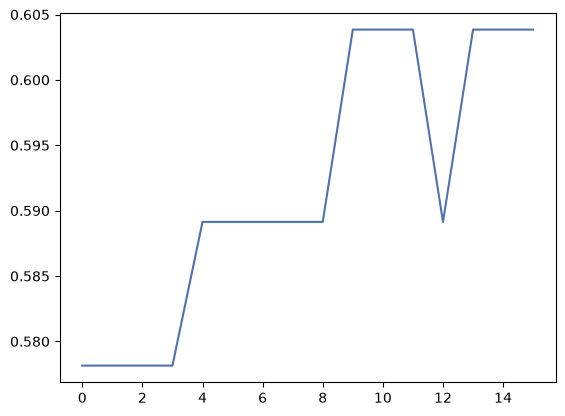

In [31]:
test_scores = gs_cv.cv_results_["mean_test_score"]
sns.lineplot(x=range(0, len(test_scores)), y=test_scores)
plt.show()

### 8 Model Evaluation

#### Final Model

In [32]:
final_model = DecisionTreeClassifier(class_weight="balanced", random_state=42, **gs_cv.best_params_)
final_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to 

#### Training Accuracy

In [33]:
tr_acc = final_model.score(X_train, y_train)
print("Training accuracy:", round(tr_acc * 100, 2))

Training accuracy: 93.88


#### Testing Accuracy

In [34]:
ts_acc = final_model.score(X_test, y_test)
print("Testing accuracy:", round(ts_acc * 100, 2))

Testing accuracy: 76.19


#### Plot Decision Tree

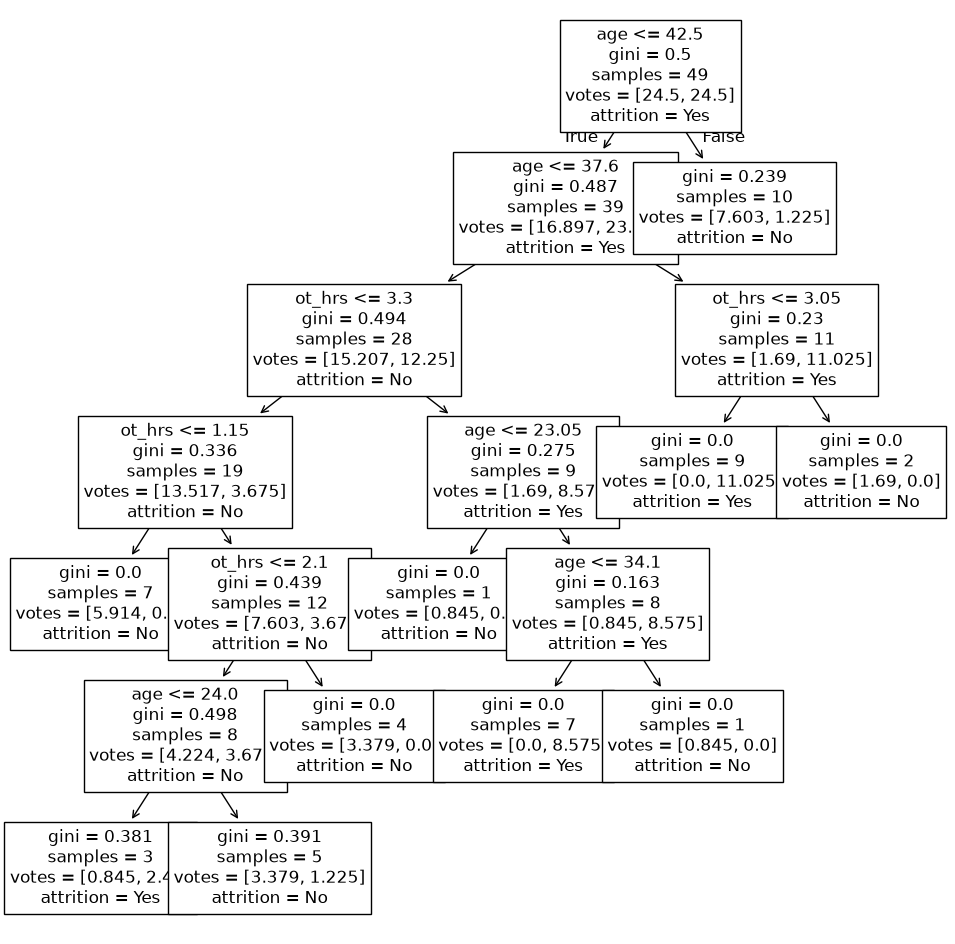

In [35]:
plt.figure(figsize=(12, 12))

plot_tree(final_model, feature_names=X.columns, class_names=["No", "Yes"], fontsize=12)

for annot in plt.gca().texts:
    text = annot.get_text()
    text = text.replace("value =", "votes =")
    text = text.replace("class =", "attrition =")
    annot.set_text(text)

plt.show()